# 04 · MIL + H04 OOF Ensemble

This notebook **trains both components independently**. It does not require results from the first three notebooks
or use an H04 model fitted on all training data to generate OOF predictions.
The default MIL component is Gated Attention; the configuration also supports Noisy-OR or Set Transformer.
Both models use the same sites, outer split, and training CV folds.

`Read MIL score × α + H04 score × (1 − α) → site score`

First lock α using training OOF predictions, then select one shared threshold on validation, and finally evaluate test data.
Allowing α=0 or 1 lets the selected blend use a single component when an ensemble does not improve the selection metric.
Outputs: `data/processed/advanced/runs/mil_h04_ensemble/<run_id>/`.


## 1. Environment

Install `requirements.txt` from the repository root and select the `.venv` kernel. All three annotated Parquet files must exist.
The shared cache is reused automatically. Notebooks 01–03 do not need to run first.


In [1]:
from pathlib import Path
import sys
import json

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src/modelling_data.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository root or AdvancedModel/ directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from AdvancedModel.common.data import prepare_store
from AdvancedModel.common.models import MILModel, ModelConfig
from AdvancedModel.common.training import (
    TrainConfig, resolve_device, create_run, run_grouped_cv, fit_final,
    predict_bags, save_mil_bundle, load_mil_bundle, mark_complete,
)
from AdvancedModel.common.evaluation import (
    select_threshold, metric_report, save_evaluation, plot_evaluation,
)
print('Project:', ROOT)
print('PyTorch:', torch.__version__)

from AdvancedModel.common.data import load_tabular_features
from AdvancedModel.common.ensemble import (
    run_h04_cv, select_oof_blend, blend_scores, fit_final_h04,
    predict_h04, save_ensemble_bundle, predict_saved_ensemble,
)


Project: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
PyTorch: 2.9.1


## 2. Configuration

The MIL training settings match those in the individual model notebooks. H04 uses its previously selected configuration:
350 iterations, 31 leaves, learning_rate=0.03, min_samples_leaf=20, and L2=2, with internal random early stopping disabled.
By default, compare 21 blend weights between 0 and 1 using mean OOF fold AP. Break ties by ROC-AUC, then prefer the smaller MIL weight.


In [2]:
# ---------- Main settings: select the device for your first run ----------
PROCESSED_DIR = ROOT / 'data/processed'
SPLIT_SEED = 42
CV_FOLDS = 5
BOOTSTRAP_REPEATS = 500

# If a pooled H04 run exists, verify identical sources, splits, and CV folds.
REFERENCE_RUN = ROOT / 'data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6'
if not REFERENCE_RUN.is_dir():
    REFERENCE_RUN = None  # A fresh checkout can prepare inputs directly from annotated files

MODEL = ModelConfig(
    architecture='gated_attention', embedding_dim=8, hidden_dim=128,
    read_dim=64, attention_dim=64, dropout=0.1, heads=4, set_layers=2,
)
TRAIN = TrainConfig(
    seed=42, device='auto', threads=4, batch_size=128, max_reads=32,
    max_epochs=25, patience=4, learning_rate=1e-3, weight_decay=1e-4,
    gradient_clip=5.0, predict_draws=5, inner_stop_fraction=0.15,
    dataset_weights=(1.0, 1.0, 1.0),  # Order: data0, data1, data2
    auxiliary_weight=0.0,           # >0 enables auxiliary regression on original data2 mixture fractions
    positive_weight='none',         # none / ratio / sqrt_ratio; computed from current fitting labels only
)
NOTEBOOK_PATH = ROOT / 'AdvancedModel/04_mil_h04_ensemble.ipynb'
print('Device:', resolve_device(TRAIN.device))
print('Reference run:', REFERENCE_RUN)

BLEND_WEIGHTS = np.linspace(0.0, 1.0, 21)


Device: mps
Reference run: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6


## 3. Data and an independent experiment directory

The neural network consumes read bags; H04 uses the existing 153 engineered site-level features.
These statistics are computed within individual sites without fitting population statistics on the complete dataset.


In [3]:
store = prepare_store(PROCESSED_DIR, seed=SPLIT_SEED, cv_folds=CV_FOLDS,
                      reference_run=REFERENCE_RUN)
summary = store.sites.groupby(['dataset', 'split']).agg(
    sites=('label', 'size'), groups=('group_id', 'nunique'),
    reads=('n_reads', 'sum'), positive_rate=('label', 'mean'),
)
display(summary)
display(store.sites.query("split == 'train'").groupby(['assessment_fold', 'dataset']).size().unstack(fill_value=0))
print('Read cache:', store.cache_dir)
print('Same human gene / synthetic construct cannot cross partitions or assessment folds.')

features = load_tabular_features(store)
RUN_DIR = create_run(store, MODEL, TRAIN, name='mil_h04_ensemble', notebook_path=NOTEBOOK_PATH)
print('MIL:', MILModel(MODEL).specification())
print('Run:', RUN_DIR)


Reusing all-read cache: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/cache/c501339a55eba5e4371a


sites  groups    reads  positive_rate
dataset split                                       
data0   test   18937     581  1640263       0.044199
        train  85166    2696  7765313       0.045147
        val    17735     575  1621530       0.044714
data1   test   13577     473  1195744       0.076600
        train  63568    2196  5555131       0.072222
        val    13665     480  1157077       0.070399
data2   test     252       1   233268       0.857143
        train    742       2   622952       0.857143
        val      329       1   315720       0.857143

dataset,data0,data1,data2
assessment_fold,,,
1,17986,13562,399
2,15662,12236,0
3,17002,12617,343
4,17227,12593,0
5,17289,12560,0


Read cache: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/cache/c501339a55eba5e4371a
Same human gene / synthetic construct cannot cross partitions or assessment folds.
data0: processed 1,999,997 reads
data0: processed 3,999,231 reads
data0: processed 5,999,895 reads
data0: processed 7,999,946 reads
data0: processed 9,999,241 reads
data0: complete, 11,027,106 reads
data1: processed 1,999,686 reads
data1: processed 3,999,251 reads
data1: processed 5,999,580 reads
data1: processed 7,907,888 reads
data1: complete, 7,907,952 reads
data2: complete, 1,171,940 reads
MIL: {'architecture': 'gated_attention', 'embedding_dim': 8, 'hidden_dim': 128, 'read_dim': 64, 'attention_dim': 64, 'dropout': 0.1, 'heads': 4, 'set_layers': 2, 'parameters': 32514}
Run: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/runs/mil_h04_ensemble/20261006T155046_7fd2138a


## 4. MIL: grouped CV and inner early stopping

Within each fold, select the epoch count, then refit on all fold-fitting sites. Outer validation and test data do not participate.
The default requires 10 CV neural-network fits, followed by one final training fit.


In [4]:
cv = run_grouped_cv(store, MODEL, TRAIN, RUN_DIR)
display(cv.fold_metrics)
display(cv.fold_metrics[['average_precision', 'roc_auc', 'pr_auc_trapezoid']].agg(['mean', 'std']))
display(pd.read_csv(RUN_DIR / 'cv_oof_metrics_by_dataset.csv'))


Fold 1: select epoch count using inner training groups
Epoch 01: loss=0.1725 | inner AP=0.4251
Epoch 02: loss=0.1507 | inner AP=0.4275
Epoch 03: loss=0.1485 | inner AP=0.4343
Epoch 04: loss=0.1468 | inner AP=0.4323
Epoch 05: loss=0.1458 | inner AP=0.4351
Epoch 06: loss=0.1448 | inner AP=0.4366
Epoch 07: loss=0.1441 | inner AP=0.4373
Epoch 08: loss=0.1427 | inner AP=0.4250
Epoch 09: loss=0.1420 | inner AP=0.4442
Epoch 10: loss=0.1410 | inner AP=0.4351
Epoch 11: loss=0.1409 | inner AP=0.4463
Epoch 12: loss=0.1400 | inner AP=0.4310
Epoch 13: loss=0.1389 | inner AP=0.4378
Epoch 14: loss=0.1386 | inner AP=0.4291
Epoch 15: loss=0.1382 | inner AP=0.4206
Fold 1: refit on all fitting groups for 11 epochs
Epoch 01: loss=0.1741
Epoch 02: loss=0.1583
Epoch 03: loss=0.1551
Epoch 04: loss=0.1539
Epoch 05: loss=0.1525
Epoch 06: loss=0.1513
Epoch 07: loss=0.1505
Epoch 08: loss=0.1494
Epoch 09: loss=0.1488
Epoch 10: loss=0.1479
Epoch 11: loss=0.1477
Fold 1: held-out AP=0.5034
Fold 2: select epoch count

,fold,epochs,fit_sites,assessment_sites,fit_groups,assessment_groups,roc_auc,average_precision,pr_auc_trapezoid
0,1,11,117529,31947,2513,629,0.885630,0.503395,0.503028
1,2,5,121578,27898,2513,629,0.862048,0.372956,0.372467
2,3,7,119514,29962,2514,628,0.862961,0.417664,0.417030
3,4,5,119656,29820,2514,628,0.874212,0.418989,0.418649
4,5,6,119627,29849,2514,628,0.868640,0.421461,0.420833


,average_precision,roc_auc,pr_auc_trapezoid
mean,0.426893,0.870698,0.426401
std,0.047273,0.009672,0.047327


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,pr_auc_trapezoid,assessment_folds
0,pooled,149476,3142,9072,0.060692,ok,0.060692,0.114439,0.870292,0.426083,0.425939,5
1,data0,85166,2696,3845,0.045147,ok,0.045147,0.086394,0.922869,0.481521,0.481233,5
2,data1,63568,2196,4591,0.072222,ok,0.072222,0.134714,0.826780,0.367690,0.367417,5
3,data2,742,2,636,0.857143,ok,0.857143,0.923077,0.854500,0.971801,0.971762,2


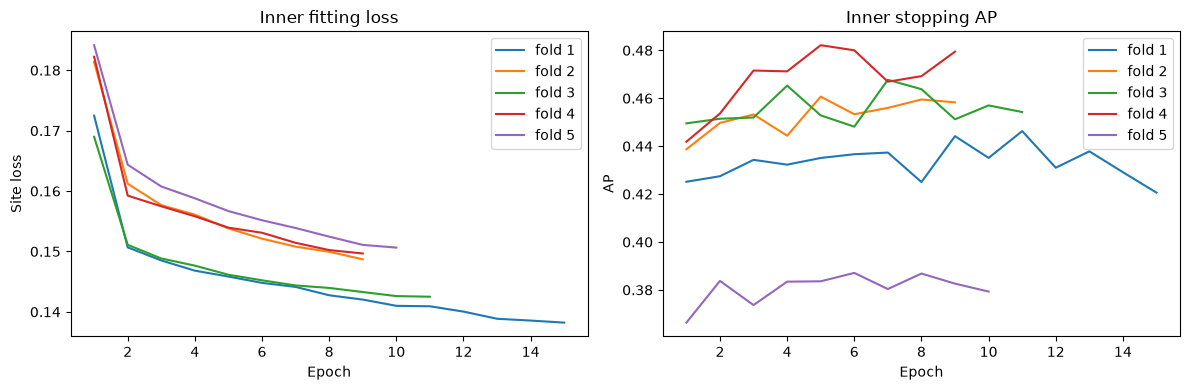

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fold, history in cv.history.query("phase == 'inner_stop'").groupby('fold'):
    axes[0].plot(history.epoch, history.training_loss, label=f'fold {fold}')
    axes[1].plot(history.epoch, history.inner_stop_ap, label=f'fold {fold}')
axes[0].set(title='Inner fitting loss', xlabel='Epoch', ylabel='Site loss')
axes[1].set(title='Inner stopping AP', xlabel='Epoch', ylabel='AP')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(RUN_DIR / 'training_curves.png', dpi=150)
plt.show()


## 5. H04: independent OOF predictions on the same folds

Fit five separate H04 models. A final model that has already seen all training data cannot substitute for these OOF fits.
Align outputs row by row using the `(dataset, transcript_id, transcript_position)` index.


In [6]:
tree_oof, tree_folds = run_h04_cv(store, features, RUN_DIR, threads=TRAIN.threads)
display(tree_folds)


H04 fold 1: AP=0.5425
H04 fold 2: AP=0.3923
H04 fold 3: AP=0.4610
H04 fold 4: AP=0.4361
H04 fold 5: AP=0.4338


,fold,roc_auc,average_precision,pr_auc_trapezoid
0,1,0.896811,0.542539,0.542406
1,2,0.869832,0.392345,0.391667
2,3,0.882644,0.461038,0.460821
3,4,0.879900,0.436131,0.435879
4,5,0.864995,0.433784,0.433227


## 6. Select the blend weight using training OOF predictions only

Verify identical indices, labels, groups, and assessment folds, and reject validation or test observations.
OOF metrics for the selected weight are development scores, not an unbiased evaluation of the entire weight-selection procedure.


,mil_weight,h04_weight,roc_auc_mean,average_precision_mean,pr_auc_trapezoid_mean,roc_auc_sd,average_precision_sd,pr_auc_trapezoid_sd
0,0.35,0.65,0.887495,0.467151,0.466768,0.011138,0.055228,0.055413
1,0.40,0.60,0.887678,0.467149,0.466820,0.011069,0.054918,0.055046
2,0.30,0.70,0.887155,0.466874,0.466495,0.011222,0.055311,0.055498
3,0.45,0.55,0.887697,0.466515,0.466188,0.011000,0.054800,0.054913
4,0.25,0.75,0.886615,0.466016,0.465640,0.011318,0.055430,0.055618


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,pr_auc_trapezoid,assessment_folds
0,pooled,149476,3142,9072,0.060692,ok,0.060692,0.114439,0.888406,0.470789,0.470677,5
1,data0,85166,2696,3845,0.045147,ok,0.045147,0.086394,0.930440,0.504290,0.504149,5
2,data1,63568,2196,4591,0.072222,ok,0.072222,0.134714,0.841373,0.405224,0.404993,5
3,data2,742,2,636,0.857143,ok,0.857143,0.923077,0.851489,0.971059,0.971026,2


Locked weights: MIL=0.35, H04=0.65


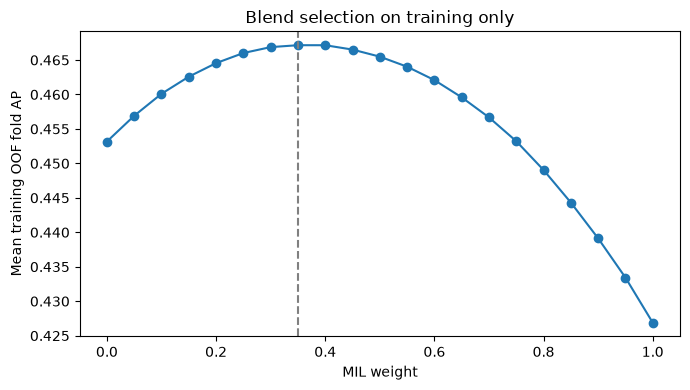

In [7]:
mil_weight, blend_search = select_oof_blend(cv.oof_predictions, tree_oof, BLEND_WEIGHTS)
blend_search.to_csv(RUN_DIR / 'blend_weight_search.csv', index=False)
blended_oof = cv.oof_predictions.copy()
blended_oof['score'] = blend_scores(cv.oof_predictions.score, tree_oof.score, mil_weight)
blended_oof.to_parquet(RUN_DIR / 'ensemble_oof_predictions.parquet')
oof_report = metric_report(store.sites.iloc[store.ids('train')], blended_oof.score.to_numpy())
oof_report.to_csv(RUN_DIR / 'ensemble_oof_metrics_by_dataset.csv', index=False)
display(blend_search.head(), oof_report)
print(f'Locked weights: MIL={mil_weight:.2f}, H04={1-mil_weight:.2f}')
fig, ax = plt.subplots(figsize=(7, 4))
curve = blend_search.sort_values('mil_weight')
ax.plot(curve.mil_weight, curve.average_precision_mean, marker='o')
ax.axvline(mil_weight, color='gray', linestyle='--')
ax.set(xlabel='MIL weight', ylabel='Mean training OOF fold AP', title='Blend selection on training only')
fig.tight_layout()
fig.savefig(RUN_DIR / 'blend_selection.png', dpi=150)
plt.show()


## 7. Fix the weights and fit both final components on all outer training data

MIL uses the median epoch count selected by CV; H04 uses its fixed configuration. Validation remains outside training.


In [8]:
model, normalizer, final_epochs = fit_final(store, MODEL, TRAIN, cv, RUN_DIR)
print('Final training epochs:', final_epochs)

tree_model = fit_final_h04(store, features, RUN_DIR, threads=TRAIN.threads)


Epoch 01: loss=0.1762
Epoch 02: loss=0.1601
Epoch 03: loss=0.1573
Epoch 04: loss=0.1555
Epoch 05: loss=0.1541
Epoch 06: loss=0.1530
Final training epochs: 6


## 8. Validation: select a threshold for the fixed blend

Select only the threshold that maximizes F1. Do not reselect the MIL architecture or blend weight using validation or test results.


In [9]:
val_ids = store.ids('val')
val_mil = predict_bags(model, normalizer, store, val_ids, TRAIN)
val_tree = predict_h04(tree_model, features, val_ids, TRAIN.threads)
val_scores = blend_scores(val_mil, val_tree, mil_weight)
threshold, threshold_search = select_threshold(store.sites.iloc[val_ids].label, val_scores)
threshold_search.to_csv(RUN_DIR / 'validation_threshold_search.csv', index=False)
display(metric_report(store.sites.iloc[val_ids], val_scores, threshold))
print('Locked threshold:', threshold)


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,...,precision,recall,f1,accuracy,balanced_accuracy,specificity,tn,fp,fn,tp
0,pooled,31729,674,2037,0.064200,ok,0.064200,0.120654,0.893726,0.512293,...,0.526242,0.556210,0.540811,0.939361,0.760929,0.965647,28672,1020,904,1133
1,data0,17735,575,793,0.044714,ok,0.044714,0.085600,0.931305,0.506668,...,0.469598,0.633039,0.539205,0.951621,0.799786,0.966533,16375,567,291,502
2,data1,13665,480,962,0.070399,ok,0.070399,0.131538,0.837656,0.410606,...,0.484954,0.435551,0.458927,0.927698,0.700260,0.964969,12258,445,543,419
3,data2,329,1,282,0.857143,ok,0.857143,0.923077,0.874906,0.977094,...,0.963636,0.751773,0.844622,0.762918,0.790780,0.829787,39,8,70,212


Locked threshold: 0.2270562014722916


## 9. Test: final evaluation of the fixed ensemble

Save pooled and per-dataset ensemble results, along with both components' ranking metrics on the same test observations.
Component metrics are descriptive and do not determine model reselection.


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,...,precision,recall,f1,accuracy,balanced_accuracy,specificity,tn,fp,fn,tp
0,pooled,32766,674,2093,0.063877,ok,0.063877,0.120084,0.895109,0.514206,...,0.520499,0.558051,0.538621,0.938931,0.761485,0.964920,29597,1076,925,1168
1,data0,18937,581,837,0.044199,ok,0.044199,0.084657,0.928982,0.514533,...,0.469618,0.646356,0.543992,0.952104,0.806300,0.966243,17489,611,296,541
2,data1,13577,473,1040,0.076600,ok,0.076600,0.142300,0.849200,0.437514,...,0.506452,0.452885,0.478173,0.924284,0.708136,0.963388,12078,459,569,471
3,data2,252,1,216,0.857143,ok,0.857143,0.923077,0.868184,0.976407,...,0.962963,0.722222,0.825397,0.738095,0.777778,0.833333,30,6,60,156


,estimate,lower_95,upper_95
average_precision,0.514206,0.478794,0.550574
roc_auc,0.895109,0.883718,0.906110
f1,0.538621,0.508446,0.571187


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,pr_auc_trapezoid,assessment_folds,component
0,pooled,32766,674,2093,0.063877,ok,0.063877,0.120084,0.881269,0.461039,0.460642,0,MIL
1,data0,18937,581,837,0.044199,ok,0.044199,0.084657,0.926376,0.496985,0.496114,0,MIL
2,data1,13577,473,1040,0.076600,ok,0.076600,0.142300,0.837257,0.404158,0.403179,0,MIL
3,data2,252,1,216,0.857143,ok,0.857143,0.923077,0.932485,0.988736,0.988710,0,MIL
4,pooled,32766,674,2093,0.063877,ok,0.063877,0.120084,0.887701,0.503984,0.503733,0,H04
5,data0,18937,581,837,0.044199,ok,0.044199,0.084657,0.920522,0.486545,0.485389,0,H04
6,data1,13577,473,1040,0.076600,ok,0.076600,0.142300,0.842151,0.422702,0.421748,0,H04
7,data2,252,1,216,0.857143,ok,0.857143,0.923077,0.819444,0.966480,0.966387,0,H04
8,pooled,32766,674,2093,0.063877,ok,0.063877,0.120084,0.895109,0.514206,0.513925,0,ensemble
9,data0,18937,581,837,0.044199,ok,0.044199,0.084657,0.928982,0.514533,0.513839,0,ensemble


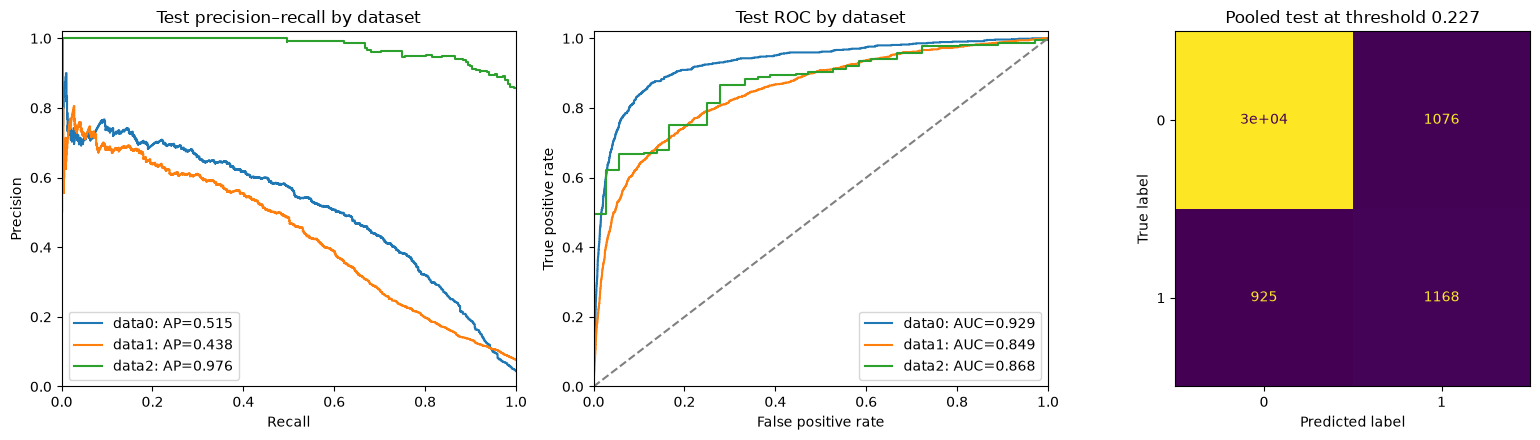

In [10]:
test_ids = store.ids('test')
test_mil = predict_bags(model, normalizer, store, test_ids, TRAIN)
test_tree = predict_h04(tree_model, features, test_ids, TRAIN.threads)
test_scores = blend_scores(test_mil, test_tree, mil_weight)
reports = save_evaluation(store, val_scores, test_scores, threshold, RUN_DIR,
                          bootstrap_repeats=BOOTSTRAP_REPEATS)
component_reports = pd.concat([
    metric_report(store.sites.iloc[test_ids], scores).assign(component=name)
    for name, scores in [('MIL', test_mil), ('H04', test_tree), ('ensemble', test_scores)]
], ignore_index=True)
component_reports.to_csv(RUN_DIR / 'test_component_ranking.csv', index=False)
store.indexed_metadata(test_ids).assign(mil_score=test_mil, h04_score=test_tree,
                                       ensemble_score=test_scores).to_parquet(RUN_DIR / 'test_component_scores.parquet')
display(reports['test'], reports['intervals'], component_reports)
plot_evaluation(store.sites.iloc[test_ids], test_scores, threshold, RUN_DIR / 'test_curves.png')
plt.show()


## 10. Save the ensemble and verify predictions after reloading both components

`model.pt` stores the MIL component without a standalone classification threshold; `h04.joblib` stores the tree model.
`ensemble.json` stores relative component paths, the blend weight, and the final threshold. Keep the complete run directory when transferring the ensemble.


In [11]:
save_mil_bundle(RUN_DIR / 'model.pt', model, normalizer, TRAIN, store,
                threshold=None, epochs=final_epochs)
save_ensemble_bundle(RUN_DIR, mil_weight, threshold, store)
check_ids = val_ids[:min(128, len(val_ids))]
reloaded_scores = predict_saved_ensemble(RUN_DIR, store, check_ids, features,
                                         device=str(resolve_device(TRAIN.device)))
np.testing.assert_allclose(reloaded_scores, val_scores[:len(check_ids)], rtol=1e-4, atol=1e-6)
mark_complete(RUN_DIR, architecture='mil_h04_ensemble', mil_architecture=MODEL.architecture,
              mil_weight=mil_weight, threshold=threshold, epochs=final_epochs)
print('PASS: reloaded ensemble matches saved predictions.')
print('Complete run:', RUN_DIR)


PASS: reloaded ensemble matches saved predictions.
Complete run: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/runs/mil_h04_ensemble/20261006T155046_7fd2138a


## 11. Interpreting the results

- Use training CV AP for model comparison and selection; avoid repeatedly selecting models from test results.
- Examine AP, precision, and recall separately for data0 and data1. Larger datasets contribute more to pooled AP.
- data2 predicts positive mixtures, has a high positive prevalence, and has only one held-out test construct.
  Reports include `prior_ap_reference` and `always_positive_f1` to put high AP and F1 values in context.
- Bootstrap sampling resamples whole groups within human and synthetic strata. The single test construct remains fixed in every draw,
  so these intervals **cannot quantify generalization uncertainty across synthetic constructs**. They also exclude training and model-selection uncertainty.
- Repeated read samples are determined by the seed, site identity, and draw number. Training on different devices is not guaranteed to be bitwise identical.
- Dataset identity, gene ID, construct ID, and label_original are not classification inputs.
  If the auxiliary loss is enabled, only training data2 label_original values provide auxiliary supervision.
